## NeuroOnco Immune 

#### API Data Harvesting

In [45]:
import requests
import pandas as pd
import numpy as np
import os

os.makedirs("figures", exist_ok=True)

def fetch_chembl_egfr_activity(target_id="CHEMBL203", limit=1000):
    base_url = "https://www.ebi.ac.uk/chembl/api/data/activity.json"
    params = {
        "target_chembl_id" : target_id,
        "standard_type" : "IC50",
        "limit" : limit
    }
    try:
        response = requests.get(base_url, params=params)
    except requests.RequestException as e:
        raise RuntimeError(f"ChEMBL request failed: {e}")
    
    if response.status_code == 200:
        data = response.json()
        print(type(data))
        print(data.keys())
        df_bio = pd.DataFrame(data["activities"])
        return df_bio
    else:
        raise RuntimeError(f"ChEMBL API request failed. Status code: {response.status_code}")

def fetch_cbioportal_gbm(study_id="gbm_tcga_pub"):
    attributes_url = f"https://www.cbioportal.org/api/studies/{study_id}/clinical-attributes"
    try:
        response = requests.get(attributes_url)
    except requests.RequestException as e:
        raise RuntimeError(f"cBioPortal API request failed. Status code: {e}")

    if response.status_code == 200:
        attributes_data = response.json()
        print(type(attributes_data))
        print(attributes_data[0])
        df_attributes = pd.DataFrame(attributes_data)
        print("Available attributes: ", df_attributes["clinicalAttributeId"].unique())
    else:
        raise RuntimeError(f"cBioPortal API request failed. Status code: {response.status_code}")
    data_url = f"https://www.cbioportal.org/api/studies/{study_id}/clinical-data"
    params = {
        "clinicalDataType" : "PATIENT"
    }
    try: 
        response = requests.get(data_url, params=params)
    except requests.RequestException as e:
        raise RuntimeError(f"cBioPortal request failed; {e}")
    print("Request URL: ", response.url)
    if response.status_code == 200:
        data = response.json()
        print(f"\nFirst clinical data record: ", data[0])
        df_cbio = pd.DataFrame(data)
        print("\nClinical-data columns:", df_cbio.columns.tolist())
        print("\nClinical attributes actually returned:", df_cbio["clinicalAttributeId"].unique())
        desired_attributes = [
            "SEX", 
            "OS_MONTHS",
            "OS_STATUS",
            "DFS_MONTHS",
            "KARNOFSKY_PERFORMANCE_SCORE",
            "SAMPLE_COUNT",
            "PRIOR_GLIOMA",
            "PRETREATMENT_HISTORY"
        ]
        df_cbio = df_cbio[df_cbio["clinicalAttributeId"].isin(desired_attributes)]
        print("Rows after filtering", df_cbio.shape)
        if df_cbio.empty:
            raise RuntimeError("No SEX, OS_MONTHS, or OS_STATUS records were returned by the clinical-data endpoint.")
        df_clinical = df_cbio.pivot(
            index="patientId",
            columns="clinicalAttributeId",
            values="value"
        ).reset_index()
        return df_clinical
    else:
        raise RuntimeError(
            f"cBioPortal clinical-data request failed. "
            f"Status code: {response.status_code}\n"
            f"{response.text}"
        )

df_chembl_raw = fetch_chembl_egfr_activity()
df_clinical_raw = fetch_cbioportal_gbm()
print("\nChEMBL", df_chembl_raw.columns.tolist())
print("\ncBioPortal", df_clinical_raw.columns.tolist())
print("ChEMBL head: ")
print(df_chembl_raw[["molecule_chembl_id", "standard_value", "standard_units", "pchembl_value"]].head())
print("cBioPortal GBM Clinical head: ")
print(df_clinical_raw[["patientId",  "SEX", "OS_MONTHS", "OS_STATUS"]].head())


<class 'dict'>
dict_keys(['activities', 'page_meta'])
<class 'list'>
{'displayName': 'ACGH Data', 'description': 'ACGH Data.', 'datatype': 'STRING', 'patientAttribute': False, 'priority': '1', 'clinicalAttributeId': 'ACGH_DATA', 'studyId': 'gbm_tcga_pub'}
Available attributes:  ['ACGH_DATA' 'CANCER_TYPE' 'CANCER_TYPE_DETAILED' 'COMPLETE_DATA'
 'DFS_MONTHS' 'DFS_STATUS' 'FRACTION_GENOME_ALTERED' 'ICD_10'
 'KARNOFSKY_PERFORMANCE_SCORE' 'MRNA_DATA' 'MUTATION_COUNT'
 'ONCOTREE_CODE' 'OS_MONTHS' 'OS_STATUS' 'PRETREATMENT_HISTORY'
 'PRIOR_GLIOMA' 'SAMPLE_COUNT' 'SAMPLE_TYPE' 'SEQUENCED' 'SEX'
 'SOMATIC_STATUS' 'TMB_NONSYNONYMOUS' 'TREATMENT_STATUS']
Request URL:  https://www.cbioportal.org/api/studies/gbm_tcga_pub/clinical-data?clinicalDataType=PATIENT

First clinical data record:  {'uniquePatientKey': 'VENHQS0wMi0wMDAxOmdibV90Y2dhX3B1Yg', 'patientId': 'TCGA-02-0001', 'studyId': 'gbm_tcga_pub', 'clinicalAttributeId': 'DFS_MONTHS', 'value': '4.504109589'}

Clinical-data columns: ['uniquePatie

#### Data Cleaning & Parsing

In [46]:
from rdkit import Chem
from rdkit.Chem import Descriptors

def clean_chembl_bioactivity(df_chembl_raw) -> pd.DataFrame:

    df = df_chembl_raw.copy() # good practice!
    df = df_chembl_raw.dropna(subset=["standard_value"])

    df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")

    if "canonical_smiles" not in df.columns and "molecule_structures" in df.columns:
        df["canonical_smiles"] = df["molecule_structures"].apply(
            lambda x: x.get("canonical_smiles") if isinstance(x, dict) and x else np.nan
        )

    mws, logps, hbas, hbds, psas = [], [], [], [], []
    
    for smiles in df["canonical_smiles"]:
        mol = Chem.MolFromSmiles(smiles) if pd.notna(smiles) and isinstance(smiles, str) else None
        if mol:
            mws.append(Descriptors.MolWt(mol))
            logps.append(Descriptors.MolLogP(mol))
            hbas.append(Descriptors.NumHAcceptors(mol))
            hbds.append(Descriptors.NumHDonors(mol))
            psas.append(Descriptors.TPSA(mol))
        else:
            mws.append(np.nan)
            logps.append(np.nan)
            hbas.append(np.nan)
            hbds.append(np.nan)
            psas.append(np.nan)

    df["MW"] = mws
    df["AlogP"] = logps
    df["HBA"] = hbas
    df["HBD"] = hbds
    df["PSA"] = psas
            
    if "pchembl_value" in df.columns:
        df["pchembl_value"] = pd.to_numeric(df["pchembl_value"], errors="coerce")
    else:
        df["pchembl_value"] = np.nan

    if "standard_units" in df.columns: 
        df = df[df["standard_units"].astype(str).str.upper() == "NM"]

    missing_mask = df["pchembl_value"].isna() & df["standard_value"].notna()
    molar_vals =  df.loc[missing_mask, "standard_value"] * 1e-9
    df.loc[missing_mask, "pchembl_value"] = -np.log10(molar_vals)

    df = df.dropna(subset=["pchembl_value", "MW"]).sort_values(by="pchembl_value", ascending=False)
    df = df.drop_duplicates(subset=["molecule_chembl_id"], keep="first").reset_index(drop=True)

    return df

def clean_cbioportal_clinical(df_clinical_raw) -> pd.DataFrame:

    df = df_clinical_raw.copy()
    numeric_candidates = [
        "OS_MONTHS",
        "DFS_MONTHS",
        "KARNOFSKY_PERFORMANCE_SCORE",
        "SAMPLE_COUNT"
    ]
    for col in numeric_candidates:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "OS_STATUS" in df.columns:
        df["OS_STATUS_CLEAN"] = df["OS_STATUS"].astype(str).str.split(":").str[-1].str.strip()

    if "OS_MONTHS" in df.columns:
        df = df.dropna(subset=["OS_MONTHS"]).reset_index(drop=True)

    return df

df_chembl_clean = clean_chembl_bioactivity(df_chembl_raw)
df_clinical_clean = clean_cbioportal_clinical(df_clinical_raw)

df_chembl_clean.to_csv("data/chembl_egfr_bioactivity_clean.csv", index=False)
df_clinical_clean.to_csv("data/tcga_gbm_clinical_clean.csv", index=False)

print("\n Cleaning Summary")
print("ChEMBL DF Shape: ", df_chembl_clean.shape)
print("Clinical Features: ", df_clinical_clean.columns.tolist())

C:\Users\Korisnik\AppData\Local\Temp\ipykernel_6152\1764193837.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")



 Cleaning Summary
ChEMBL DF Shape:  (780, 52)
Clinical Features:  ['patientId', 'DFS_MONTHS', 'KARNOFSKY_PERFORMANCE_SCORE', 'OS_MONTHS', 'OS_STATUS', 'PRETREATMENT_HISTORY', 'PRIOR_GLIOMA', 'SAMPLE_COUNT', 'SEX', 'OS_STATUS_CLEAN']


C:\Users\Korisnik\AppData\Local\Temp\ipykernel_6152\1764193837.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["MW"] = mws
C:\Users\Korisnik\AppData\Local\Temp\ipykernel_6152\1764193837.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["AlogP"] = logps
C:\Users\Korisnik\AppData\Local\Temp\ipykernel_6152\1764193837.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the doc

In [47]:
def analyze_chembl_dispersion(df_chembl) -> dict:
    pchembl = df_chembl["pchembl_value"].dropna()
    pchembl_range = pchembl.max() - pchembl.min()
    pchembl_std = pchembl.std()

    q25 = pchembl.quantile(0.25)
    q75 = pchembl.quantile(0.75)
    iqr = q75 - q25

    lower_bound = q25 - (1.5 * iqr)
    upper_bound = q75 + (1.5 * iqr)
    outliers = df_chembl[
        (df_chembl["pchembl_value"] < lower_bound) |
        (df_chembl["pchembl_value"] > upper_bound)
    ]

    metrics = {
        "count" : len(pchembl),
        "mean" : pchembl.mean(),
        "median" : pchembl.median(),
        "range" : pchembl_range,
        "iqr" : iqr,
        "std" : pchembl_std,
        "num_outliers" : len(outliers)
    }

    print("ChEMBL EGFR Bioactivity Dispersion")
    for k, v in metrics.items():
        print (f"{k} : {v:.3f}" if isinstance(v, float) else f"{k} : {v}")

    return metrics

def analyze_clinical_dispersion(df_clinical) -> pd.DataFrame:
    def compute_iqr(x):
        return x.quantile(0.75) - x.quantile(0.25)

    stats_df = (
        df_clinical
        .groupby("OS_STATUS_CLEAN")["OS_MONTHS"]
        .agg(["count", "mean", "median", "std", compute_iqr])
        .rename(columns={"compute_iqr" : "iqr"})
    )

    print("cBioPortal Glioblastoma Survival by Status")
    print(stats_df)

    return stats_df

chembl_stats = analyze_chembl_dispersion(df_chembl_clean)
clinical_stats = analyze_clinical_dispersion(df_clinical_clean)

ChEMBL EGFR Bioactivity Dispersion
count : 780
mean : 5.969
median : 5.690
range : 9.035
iqr : 2.431
std : 1.753
num_outliers : 4
cBioPortal Glioblastoma Survival by Status
                 count       mean     median        std        iqr
OS_STATUS_CLEAN                                                   
DECEASED           194  17.817314  12.476712  18.700373  12.961644
LIVING              12  41.536986  38.695890  22.393938  26.835616


#### Visualizations

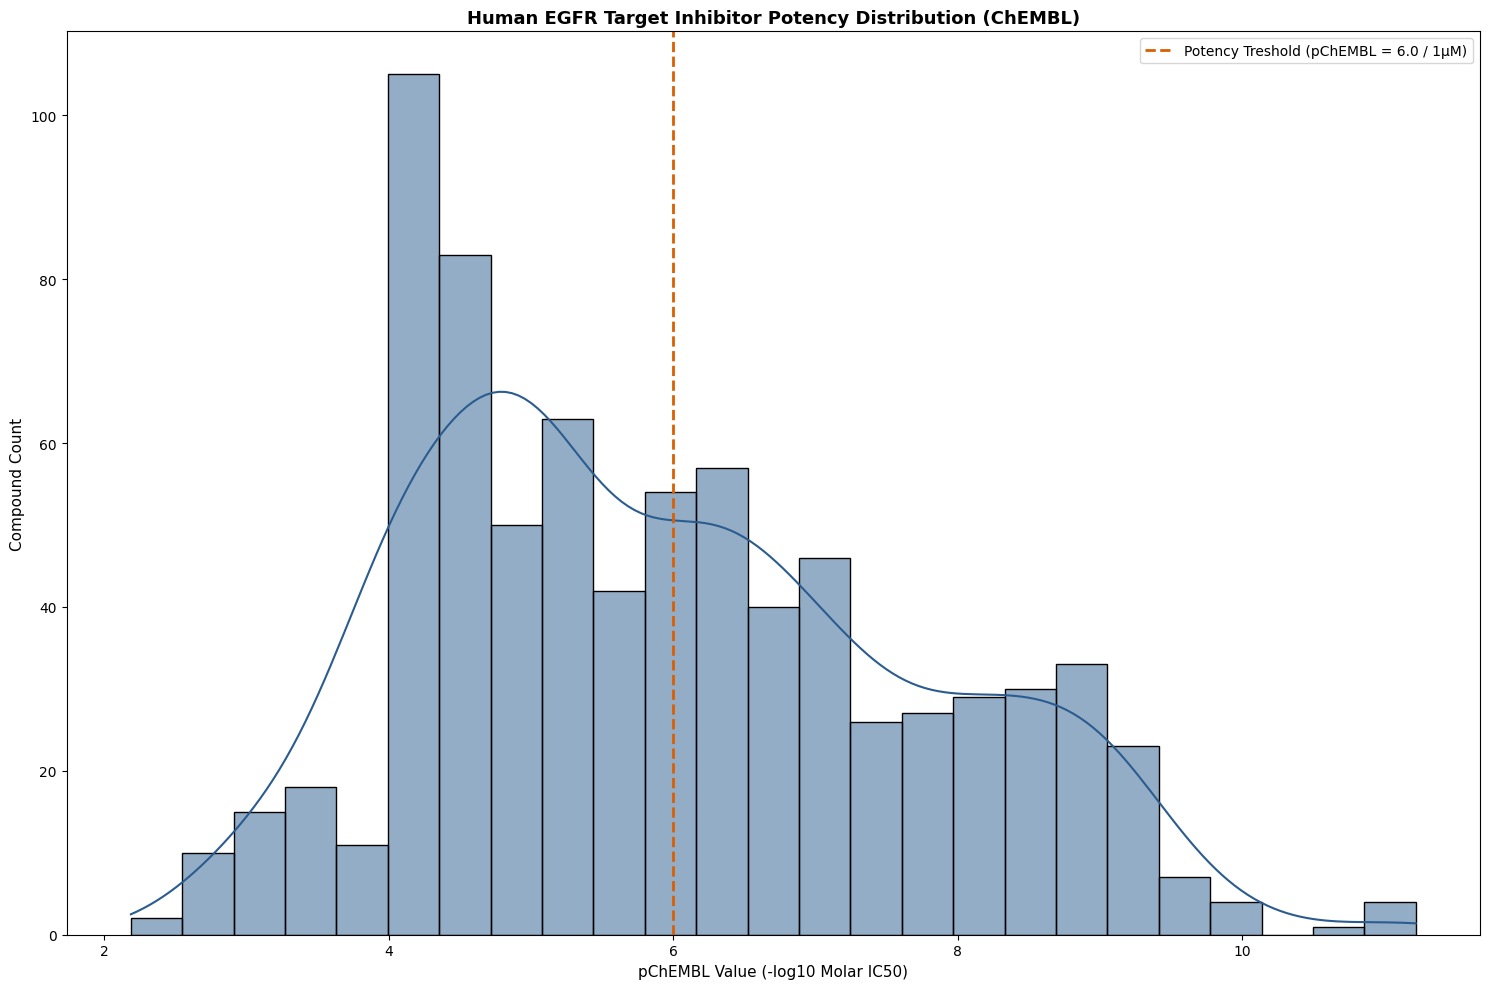

C:\Users\Korisnik\AppData\Local\Temp\ipykernel_6152\2250773341.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Korisnik\AppData\Local\Temp\ipykernel_6152\2250773341.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


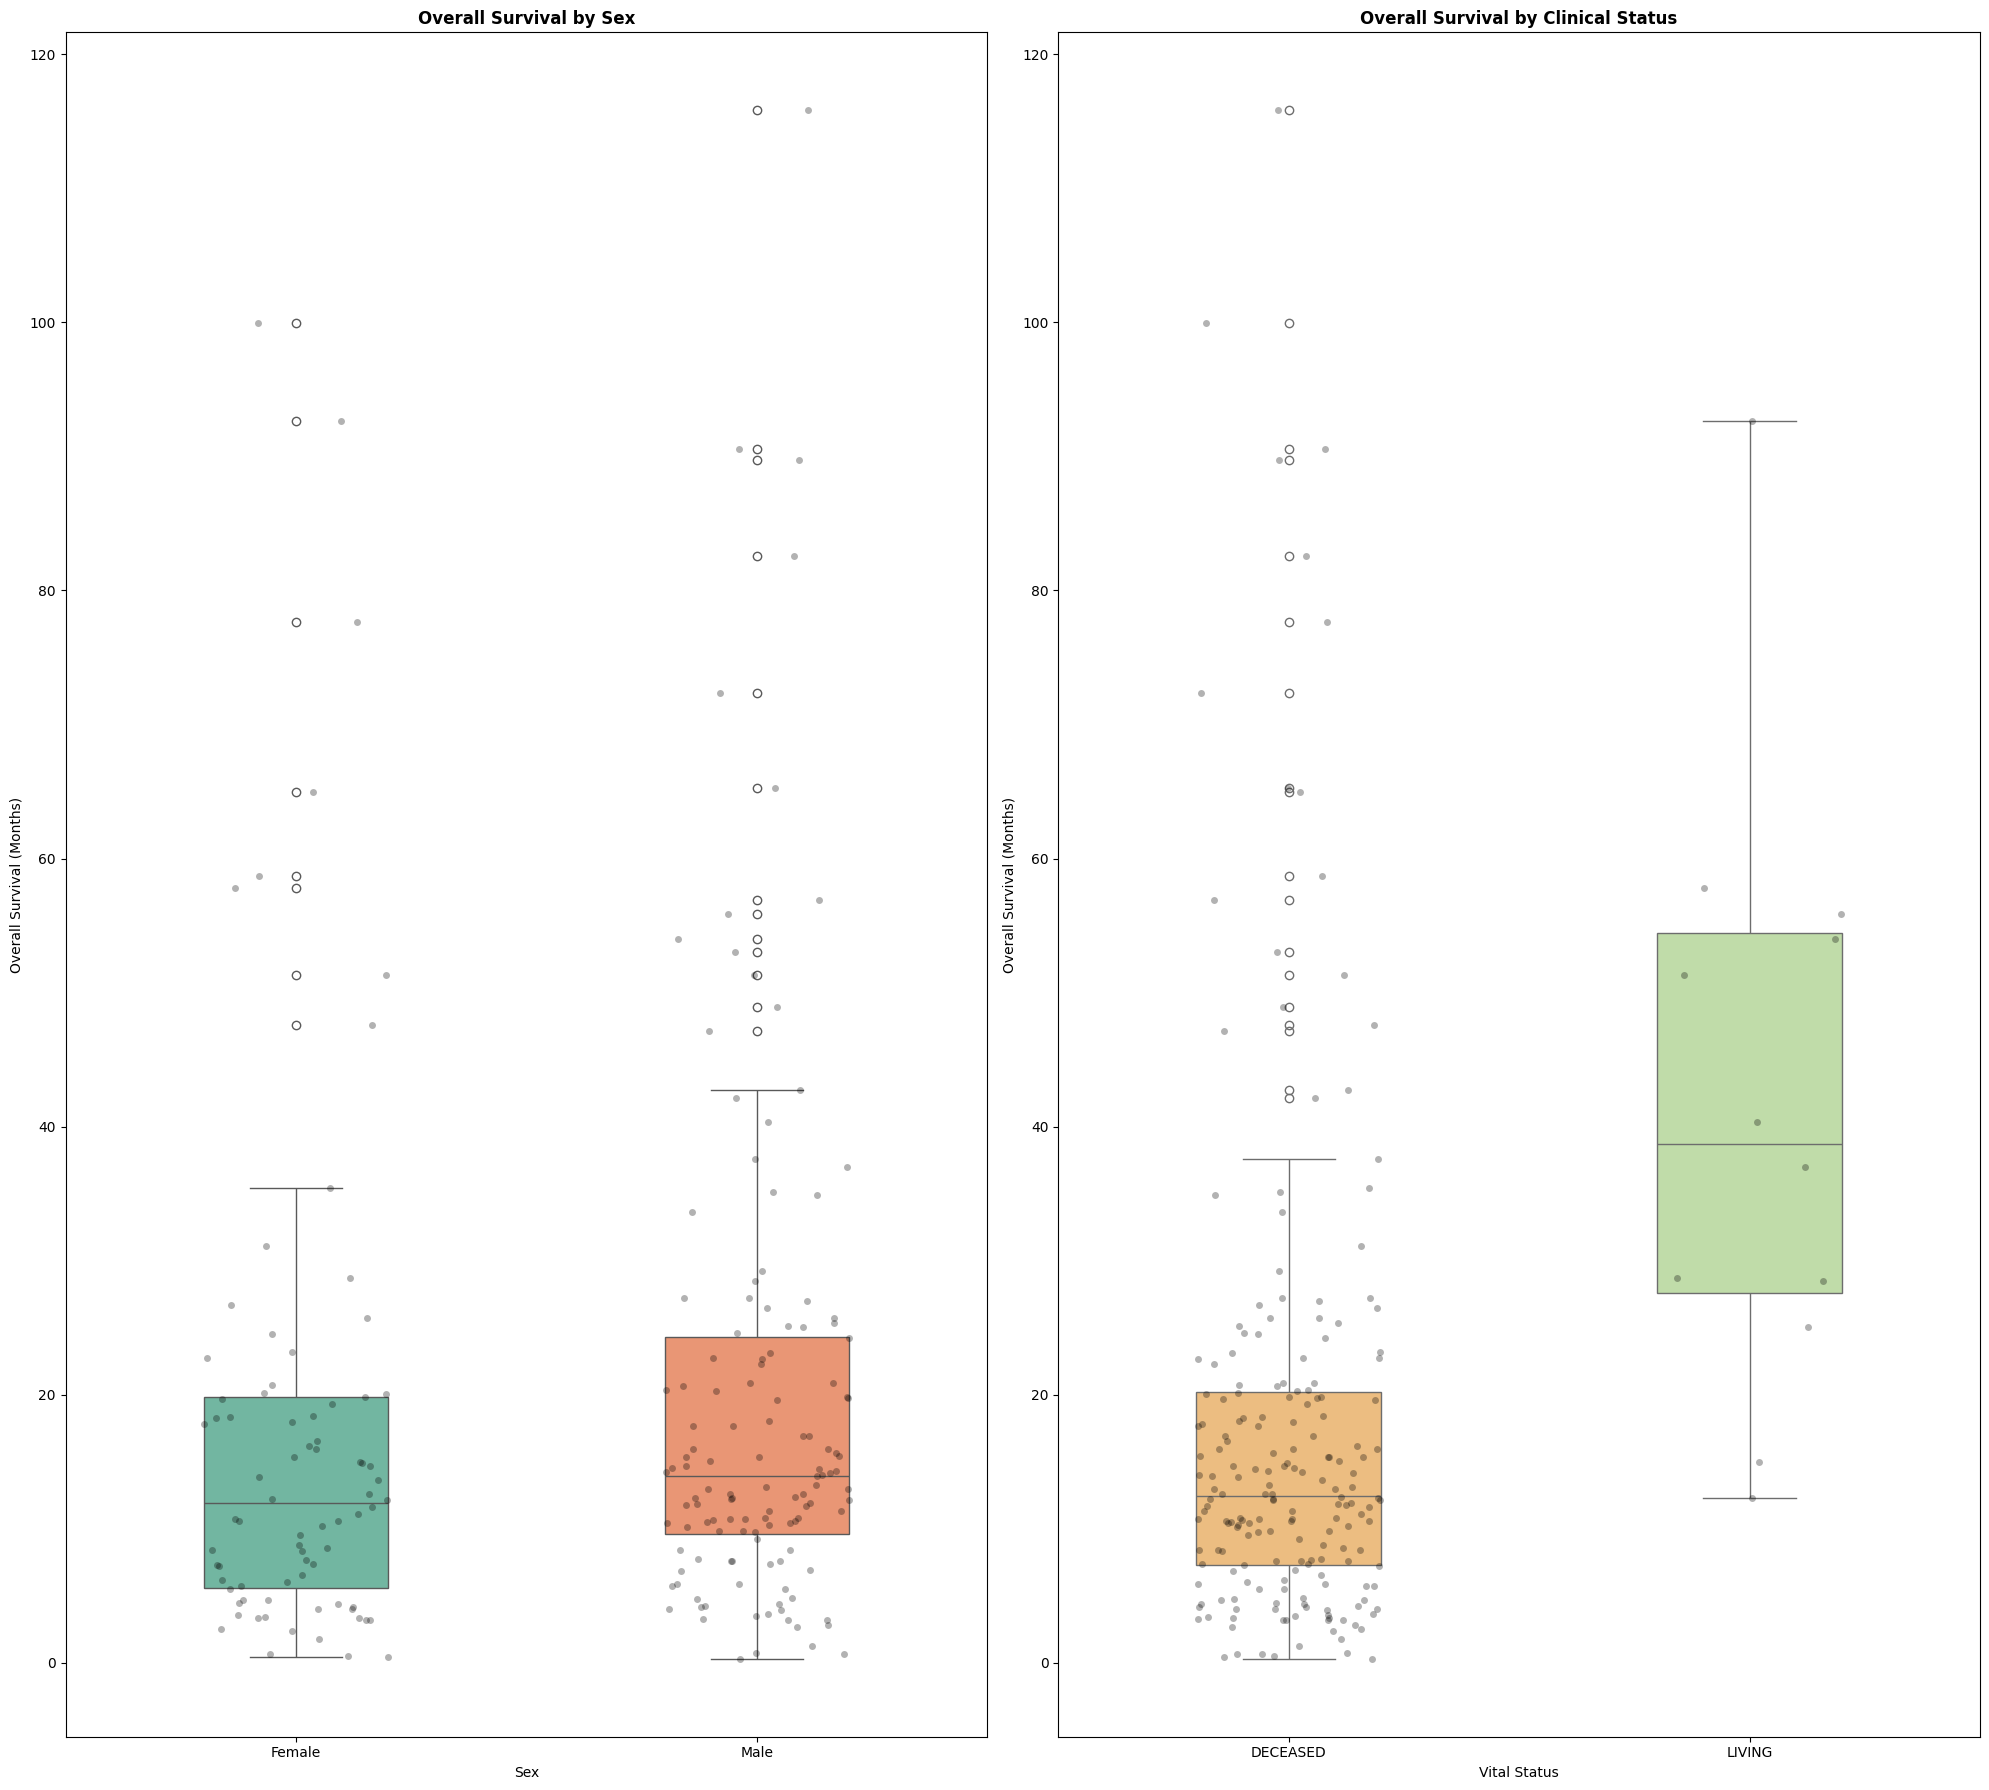

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_target_bioactivity_profiles(df_chembl):

    fig, ax = plt.subplots(figsize=(15,10))

    sns.histplot(
        data=df_chembl, 
        x="pchembl_value",
        kde=True,
        color="#2b5c8f",
        bins=25,
        ax=ax
    )

    ax.axvline(
        x=6.0,
        color="#d95f02",
        linestyle="--",
        linewidth=2,
        label="Potency Treshold (pChEMBL = 6.0 / 1µM)"
    )

    ax.set_title("Human EGFR Target Inhibitor Potency Distribution (ChEMBL)", fontsize=13, fontweight="bold")
    ax.set_xlabel("pChEMBL Value (-log10 Molar IC50)", fontsize=11)
    ax.set_ylabel("Compound Count", fontsize=11)
    ax.legend(loc="upper right")
    
    plt.tight_layout()
    plt.savefig("figures/fig1.png")
    plt.show()

def plot_clinical_survival_subgroups(df_clinical):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 18))

    if "SEX" in df_clinical.columns:
        sns.boxplot(
            data=df_clinical,
            x="SEX",
            y="OS_MONTHS",
            palette="Set2",
            ax=ax1,
            width=0.4
        )
        sns.stripplot(
            data=df_clinical,
            x="SEX",
            y="OS_MONTHS",
            color="black",
            alpha=0.3,
            jitter=0.2,
            ax=ax1
        )
        ax1.set_title("Overall Survival by Sex", fontsize=12, fontweight="bold")
        ax1.set_xlabel("Sex", fontsize=10)
        ax1.set_ylabel("Overall Survival (Months)", fontsize=10)
    
    if "OS_STATUS_CLEAN" in df_clinical.columns:
        sns.boxplot(
            data=df_clinical,
            x="OS_STATUS_CLEAN",
            y="OS_MONTHS",
            palette="Spectral",
            ax=ax2,
            width=0.4
        )
        sns.stripplot(
            data=df_clinical,
            x="OS_STATUS_CLEAN",
            y="OS_MONTHS",
            color="black",
            alpha=0.3,
            jitter=0.2,
            ax=ax2
        )
        ax2.set_title("Overall Survival by Clinical Status", fontsize=12, fontweight="bold")
        ax2.set_xlabel("Vital Status", fontsize=10)
        ax2.set_ylabel("Overall Survival (Months)", fontsize=10)
        
    plt.tight_layout()
    plt.savefig("figures/fig2.png")
    plt.show()

plot_target_bioactivity_profiles(df_chembl_clean)
plot_clinical_survival_subgroups(df_clinical_clean)

### EDA & Survival Profiling

In [49]:
def plot_pchembl_distribution(df_chembl):
     plt.figure(figsize=(8,5))

     sns.histplot(
          df_chembl["pchembl_value"],
          kde=True,
          color="teal",
          bins=30
     )

     plt.axvline(
          6.0, 
          color="red", 
          linestyle="--", 
          label="Potency Treshold - $IC{50}"
    )
     plt.title("Distribution of Pan-Kinase Bioactivity")
     plt.xlabel("pChEMBL value (-log10 Molar)")
     plt.ylabel("Frequency")

     plt.tight_layout()
     plt.savefig("figures/fig3.png")
     plt.show()

def plot_kps_survival_stratification(df_clinical):
     if "KARNOFSKY_PERFORMANCE_SCORE" in df_clinical.columns and "OS_MONTHS" in df_clinical.columns:
          
          df_plot = df_clinical.dropna(subset=["KARNOFSKY_PERFORMANCE_SCORE", "OS_MONTHS"]).copy()
          df_plot["KPS_GROUP"] = np.where(df_plot["KARNOFSKY_PERFORMANCE_SCORE"] >= 80, "High KPS (>=80)", "Low KPS (<80)")

          plt.figure(figsize=(7, 4.5))
          sns.boxplot(
               data=df_plot, 
               x="KPS_GROUP", 
               y="OS_MONTHS", 
               palette="Set2"
          )
          sns.stripplot(
               data=df_plot, 
               x="KPS_GROUP", 
               y="OS_MONTHS", 
               color="black", 
               alpha=0.3, 
               jitter=0.2
          )

          plt.title("Overall Survival (OS) Months Stratified by Functional Status")
          plt.xlabel("Karnofsky Performance Score Group")
          plt.ylabel("Overall Survival (Months)")

          plt.tight_layout()
          plt.savefig("figures/fig4.png")
          plt.show()


#### Feature Engineering

In [50]:
def engineer_features(df_chembl, df_clinical):
    group_col = "target_chembl_id" if "target_chembl_id" in df_chembl.columns else "assay_chembl_id"
    
    target_summary = df_chembl.groupby(group_col).agg(
        mean_pchembl=("pchembl_value", "mean"),
        max_pchembl=("pchembl_value", "max"),
        inhibitor_count=("molecule_chembl_id", "nunique")
    ).reset_index()
    
    cat_cols = [c for c in ["SEX", "PRIOR_GLIOMA", "PRETREATMENT_HISTORY"] if c in df_clinical.columns]
    clinical_encoded = pd.get_dummies(df_clinical, columns=cat_cols, drop_first=True)

    return target_summary, clinical_encoded

#### Machine Learning Pipeline

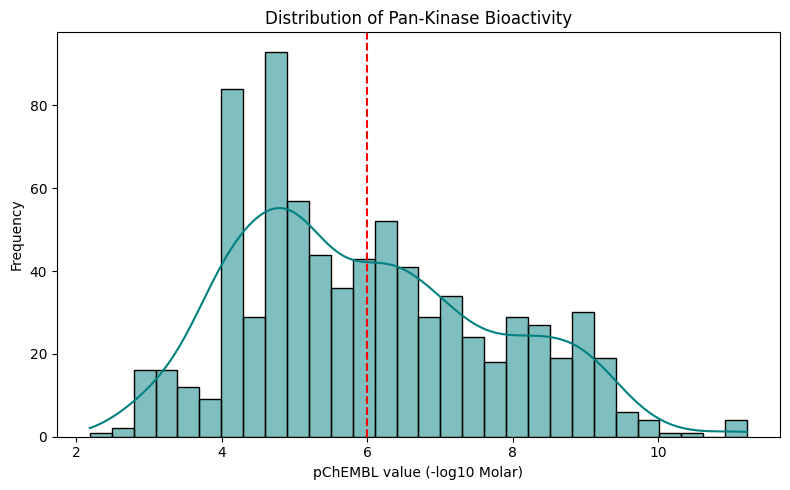

C:\Users\Korisnik\AppData\Local\Temp\ipykernel_6152\1368645607.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


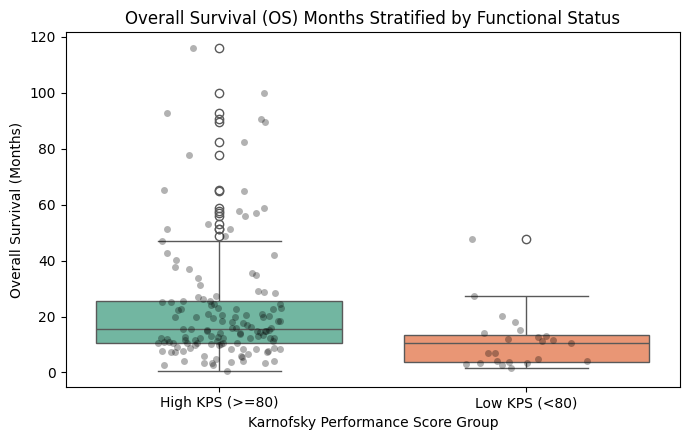


Features selected for training: ['MW', 'AlogP', 'HBA', 'HBD', 'PSA']
ML Evaluation Metrics
Features Used: 5
Test Set RMSE: 1.1370
Test Set R^2: 0.5944


In [52]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

def train_affinity_predictor(df_chembl):
    df = df_chembl.copy()

    feature_cols = ["MW", "AlogP", "HBA", "HBD", "PSA"]

    feature_cols = [col for col in feature_cols if col in df.columns]

    if not feature_cols:
        raise ValueError("No molecular descriptors generated. Check SMILES parsing.")
        
    print(f"\nFeatures selected for training: {feature_cols}")

    X = df[feature_cols].copy()
    X = X.fillna(X.median())
    y = df["pchembl_value"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

    rf = RandomForestRegressor(n_estimators=150, max_depth=10, min_samples_split=5, random_state=42)
    rf.fit(X_train, y_train)

    preds = rf.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print("ML Evaluation Metrics")
    print(f"Features Used: {len(feature_cols)}")
    print(f"Test Set RMSE: {rmse:.4f}")
    print(f"Test Set R^2: {r2:.4f}")

    return rf

plot_pchembl_distribution(df_chembl_clean)
plot_kps_survival_stratification(df_clinical_clean)
target_summary, clinical_encoded = engineer_features(df_chembl_clean, df_clinical_clean)
model = train_affinity_predictor(df_chembl_clean)
